# TorchGeo FTW segmentation -> contourrs polygons

This notebook runs `Unet_Weights.SENTINEL2_FTW_PRUE_CCBY_EFNETB3` on a Fields of the World sample and polygonizes only class index `1` (field) with `contourrs.shapes`.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import torch
from contourrs import shapes
from torchgeo.datasets import FieldsOfTheWorld
from torchgeo.models import Unet_Weights, unet

/home/isaaccorley/github/contourrs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = FieldsOfTheWorld(
    root="data",
    split="test",
    target="3-class",
    countries="spain",
    download=True,
)

idx = 50
sample = ds[idx]

In [3]:
weights = Unet_Weights.SENTINEL2_FTW_PRUE_CCBY_EFNETB3
transforms = weights.transforms
model = unet(weights=weights).eval()

with torch.inference_mode():
    logits = model(transforms(sample["image"].unsqueeze(0)))

prediction = logits.squeeze(0).argmax(dim=0).cpu().numpy().astype(np.uint8)
prediction.shape

Downloading: "https://hf.co/isaaccorley/ftw-prue-ccby/resolve/ce7ffffbceb1b55b3b6db77ecbc82313b7afa163/prue_efnetb3_ccby-aa82bfe9.pth" to /home/isaaccorley/.cache/torch/hub/checkpoints/prue_efnetb3_ccby-aa82bfe9.pth


100%|██████████| 50.8M/50.8M [00:03<00:00, 13.4MB/s]


(256, 256)

In [14]:
class_index = 1
class_mask = prediction == class_index

features = [
    {
        "type": "Feature",
        "properties": {"class_idx": int(value)},
        "geometry": geometry,
    }
    for geometry, value in shapes(
        class_mask.astype(np.uint8),
        mask=class_mask,
        connectivity=4,
    )
    if int(value) == 1
]

field_polygons = gpd.GeoDataFrame.from_features(features)
field_polygons.head()

,geometry,class_idx
0,"POLYGON ((0 0, 1 0, 2 0, 3 0, 4 0, 5 0, 6 0, 7...",1
1,"POLYGON ((49 0, 50 0, 51 0, 52 0, 53 0, 54 0, ...",1
2,"POLYGON ((116 0, 117 0, 118 0, 119 0, 120 0, 1...",1
3,"POLYGON ((144 0, 145 0, 146 0, 147 0, 148 0, 1...",1
4,"POLYGON ((169 0, 170 0, 171 0, 172 0, 173 0, 1...",1


(256, 256, 3) float32 0.10566667 1.0
Saved assets/torchgeo_ftw_polygonize.png
Saved docs/assets/torchgeo_ftw_polygonize.png


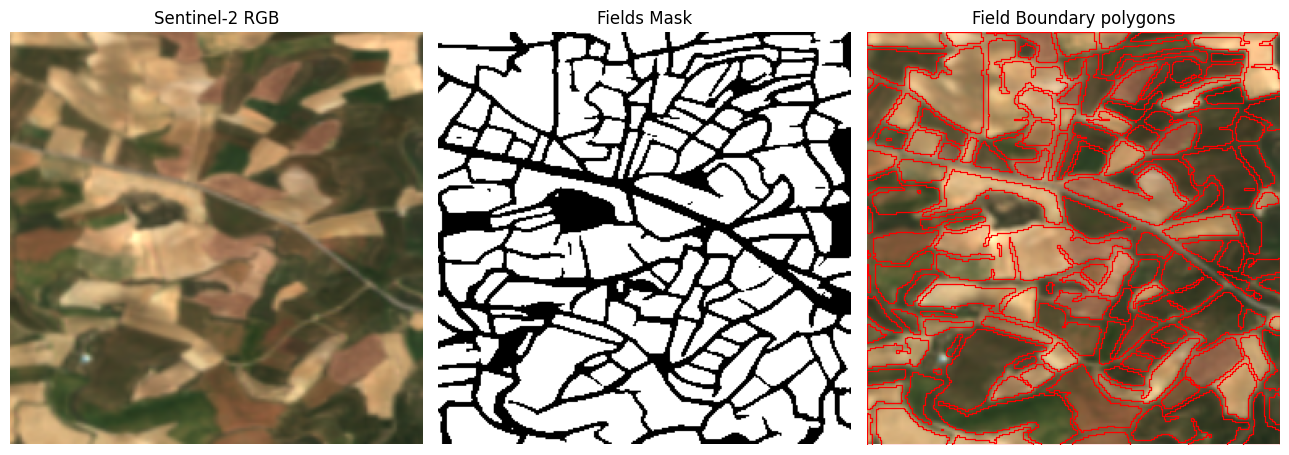

In [17]:
image = sample["image"].cpu().numpy()
rgb = np.clip(np.moveaxis(image[:3], 0, -1), 0.0, 1.0)
h, w = prediction.shape
print(rgb.shape, rgb.dtype, rgb.min(), rgb.max())
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(rgb, interpolation="nearest")
axes[0].set_title("Sentinel-2 RGB")

axes[1].imshow(class_mask, cmap="gray", interpolation="nearest")
axes[1].set_title("Fields Mask")

axes[2].imshow(rgb, interpolation="nearest")
field_polygons.boundary.plot(ax=axes[2], color="red", linewidth=0.9)
axes[2].set_title("Field Boundary polygons")

for ax in axes:
    ax.set_axis_off()
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.set_aspect("equal")

plt.tight_layout()
for out_dir in (Path("assets"), Path("docs/assets")):
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "torchgeo_ftw_polygonize.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    print(f"Saved {out_path}")
plt.show()

In [6]:
output_path = Path("examples/output/ftw_fields_idx50.parquet")
output_path.parent.mkdir(parents=True, exist_ok=True)
field_polygons.to_parquet(output_path, index=False)
output_path

PosixPath('examples/output/ftw_fields_idx50.parquet')